<a href="https://colab.research.google.com/github/Pumlisa97/mit805-airline-delays-pyspark/blob/MCMthethwa-Dev/notebooks/02_part1_pyspark_preparation_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: PySpark Data Preparation and Exploratory Data Analysis

## MIT 805 Big Data Semester Project

**Dataset:** U.S. Department of Transportation Bureau of Transportation Statistics
(BTS) Reporting Carrier On-Time Performance (1987–present)

**Working dataset:** January 2020–December 2024, 60 monthly CSV files  
**Raw public dataset:** January 2015–December 2024, 120 monthly CSV files  
**Research question:** How do departure delays, arrival delays, and cancellations
vary by airline, origin airport, month, and scheduled departure period, and which
operational delay categories account for the greatest disruption?

This notebook prepares the PySpark processing dataset and performs initial data
quality assessment and exploratory data analysis. Large-scale transformations and
aggregations are performed in PySpark. Pandas is used only for small result tables
or visualisations after aggregation.

In [1]:
!pip -q install pyspark==3.5.1 pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 10.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [3]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_ROOT = Path("/content/drive/MyDrive/MIT805_Airline_Delays/data")
WORKING_DIR = DATA_ROOT / "working"
PROCESSED_DIR = DATA_ROOT / "processed"
TEMP_DIR = DATA_ROOT / "temp"

print(f"Working directory exists: {WORKING_DIR.exists()}")
print(f"Processed directory exists: {PROCESSED_DIR.exists()}")
print(f"Working CSV files: {len(list(WORKING_DIR.glob('*.csv')))}")

Mounted at /content/drive
Working directory exists: True
Processed directory exists: True
Working CSV files: 60


In [4]:
import pyspark

print(f"PySpark version: {pyspark.__version__}")

PySpark version: 4.0.4


In [5]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MIT805_Airline_Delays_Part1")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Application name: {spark.sparkContext.appName}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")

Spark version: 4.0.4
Application name: MIT805_Airline_Delays_Part1
Default parallelism: 2


In [6]:
!ls "/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024"

 _SUCCESS  'Year=2020'	'Year=2021'  'Year=2022'  'Year=2023'  'Year=2024'


In [7]:
!find "/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024" | head -20

/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=10
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=10/part-00000-8a6bc4bc-d3de-4762-9b52-a70ffc969c6a.c000.snappy.parquet
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=10/.part-00000-8a6bc4bc-d3de-4762-9b52-a70ffc969c6a.c000.snappy.parquet.crc
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=4
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=4/part-00009-8a6bc4bc-d3de-4762-9b52-a70ffc969c6a.c000.snappy.parquet
/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/Year=2022/Month=4/.part-

In [8]:
df = spark.read.option("basePath",
    "/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024"
).parquet(
    "/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024/*/*"
)

In [9]:
df.head()

Row(Reporting_Airline='9E', IATA_CODE_Reporting_Airline='9E', Flight_Number_Reporting_Airline='4800', Origin='CHS', OriginCityName='Charleston, SC', OriginState='SC', OriginStateName='South Carolina', Dest='JFK', DestCityName='New York, NY', DestState='NY', DestStateName='New York', DepTimeBlk='0700-0759', ArrTimeBlk='0900-0959', CancellationCode=None, Quarter=3, DayofMonth=1, DayOfWeek=1, DOT_ID_Reporting_Airline=20363, CRSDepTime=700, DepTime=656, DepDel15=0, CRSArrTime=900, ArrTime=900, ArrDel15=0, Cancelled=0, Diverted=0, DistanceGroup=3, FlightDate=datetime.date(2024, 7, 1), DepDelay=-4.0, DepDelayMinutes=0.0, ArrDelay=0.0, ArrDelayMinutes=0.0, CRSElapsedTime=120.0, ActualElapsedTime=124.0, AirTime=91.0, Distance=636.0, CarrierDelay=None, WeatherDelay=None, NASDelay=None, SecurityDelay=None, LateAircraftDelay=None, source_file='file:///content/drive/MyDrive/MIT805_Airline_Delays/data/working/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_7.csv', ScheduledDepHour

In [8]:
print(f"Columns: {len(df.columns)}")
print(f"Rows: {df.count():,}")

Columns: 46
Rows: 30,241,436


In [10]:
# Flights by year
from pyspark.sql import functions as F

df.groupBy("Year") \
  .count() \
  .orderBy("Year") \
  .show()

+----+-------+
|Year|  count|
+----+-------+
|2020|4688354|
|2021|5416218|
|2022|6729125|
|2023|6847899|
|2024|6559840|
+----+-------+



In [11]:
#airlines
airlines = df.select("Reporting_Airline").distinct().count()

print(f"Number of airlines: {airlines}")

Number of airlines: 18


In [12]:
# airpots
airports = df.select("Origin").distinct().count()

print(f"Number of origin airports: {airports}")

Number of origin airports: 380


In [13]:
# top 10 busiest airpots
df.groupBy("Origin") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(10)

+------+-------+
|Origin|  count|
+------+-------+
|   ATL|1511980|
|   DFW|1332886|
|   DEN|1281320|
|   ORD|1184850|
|   CLT| 942918|
|   LAX| 846078|
|   PHX| 789083|
|   LAS| 781788|
|   SEA| 742931|
|   MCO| 673594|
+------+-------+
only showing top 10 rows


In [15]:
# Delay statistics
df.select(
    "DepDelay",
    "ArrDelay"
).describe().show()

+-------+------------------+-----------------+
|summary|          DepDelay|         ArrDelay|
+-------+------------------+-----------------+
|  count|          29525634|         29443240|
|   mean|10.392731922369558|4.442034572282126|
| stddev| 51.19760314741591|53.06227264607572|
|    min|            -128.0|           -139.0|
|    max|            4413.0|           4405.0|
+-------+------------------+-----------------+



In [14]:
# Delay causes
df.groupBy("Reporting_Airline") \
  .agg(
      (F.avg("Cancelled") * 100)
      .alias("CancellationRate")
  ) \
  .orderBy(F.desc("CancellationRate")) \
  .show(10)

+-----------------+------------------+
|Reporting_Airline|  CancellationRate|
+-----------------+------------------+
|               EV| 7.739522393785365|
|               G4| 4.481936985648564|
|               YV|  4.15368692223794|
|               YX|3.0658091735715627|
|               OH|2.8329033440617137|
|               WN|2.7759897733204175|
|               B6|2.7662792512626067|
|               F9| 2.603278511873493|
|               AA|2.4814613196012396|
|               MQ| 2.360333630935205|
+-----------------+------------------+
only showing top 10 rows


In [10]:
from pyspark.sql import functions as F

df.groupBy("Reporting_Airline") \
  .agg(
      F.avg("DepDelay").alias("AvgDepDelay"),
      F.avg("ArrDelay").alias("AvgArrDelay")
  ) \
  .orderBy(F.desc("AvgDepDelay")) \
  .show(20)

+-----------------+--------------------+-------------------+
|Reporting_Airline|         AvgDepDelay|        AvgArrDelay|
+-----------------+--------------------+-------------------+
|               B6|  18.381606547165635|  12.40617553024585|
|               F9|   16.85063141414937| 12.420298125427644|
|               AA|  14.771957220675207|   8.73218234477583|
|               G4|  14.277456336904141| 12.931035146549833|
|               NK|  13.914554144764551|  8.543769488563282|
|               YV|  11.512883163624753|  5.689744444973873|
|               WN|  10.932754912022112|  3.683222155311518|
|               UA|  10.747609919369353|   4.09341905069465|
|               OO|   8.987013982504442| 3.7905342282041734|
|               OH|   8.528477456086213|  4.409715691128908|
|               DL|     8.3619546714375|  1.324265489667307|
|               MQ|   6.788179346645936|  2.985449685898949|
|               HA|   6.068927223855735|  4.774617413414615|
|               9E|   5.

In [11]:
df.select(
    F.sum("CarrierDelay").alias("CarrierDelay"),
    F.sum("WeatherDelay").alias("WeatherDelay"),
    F.sum("NASDelay").alias("NASDelay"),
    F.sum("SecurityDelay").alias("SecurityDelay"),
    F.sum("LateAircraftDelay").alias("LateAircraftDelay")
).show()

+------------+------------+-----------+-------------+-----------------+
|CarrierDelay|WeatherDelay|   NASDelay|SecurityDelay|LateAircraftDelay|
+------------+------------+-----------+-------------+-----------------+
|1.40723851E8|  2.187013E7|6.6883585E7|     836985.0|     1.41312882E8|
+------------+------------+-----------+-------------+-----------------+



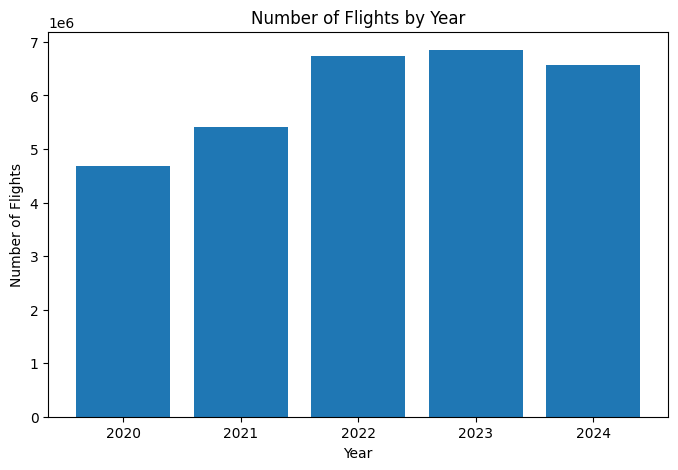

In [13]:
import matplotlib.pyplot as plt

flights_year = (
    df.groupBy("Year")
      .count()
      .orderBy("Year")
      .toPandas()
)

plt.figure(figsize=(8,5))
plt.bar(flights_year["Year"].astype(str), flights_year["count"])

plt.title("Number of Flights by Year")
plt.xlabel("Year")
plt.ylabel("Number of Flights")

plt.show()

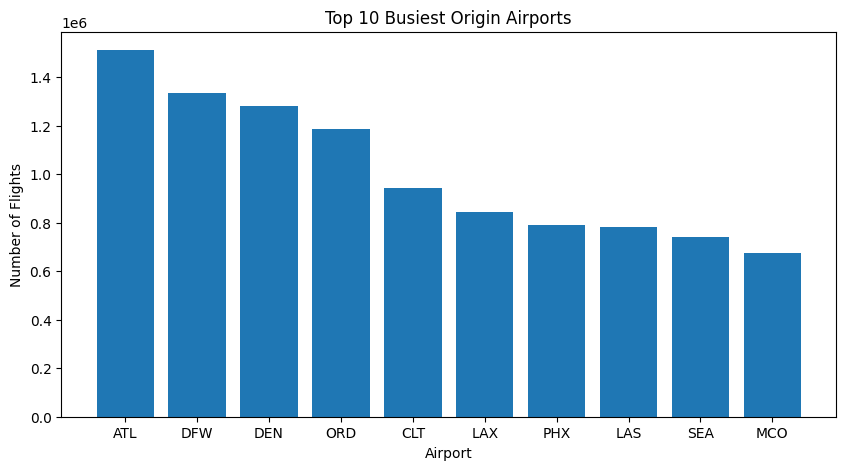

In [14]:
top_airports = (
    df.groupBy("Origin")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10,5))
plt.bar(top_airports["Origin"], top_airports["count"])

plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")

plt.show()

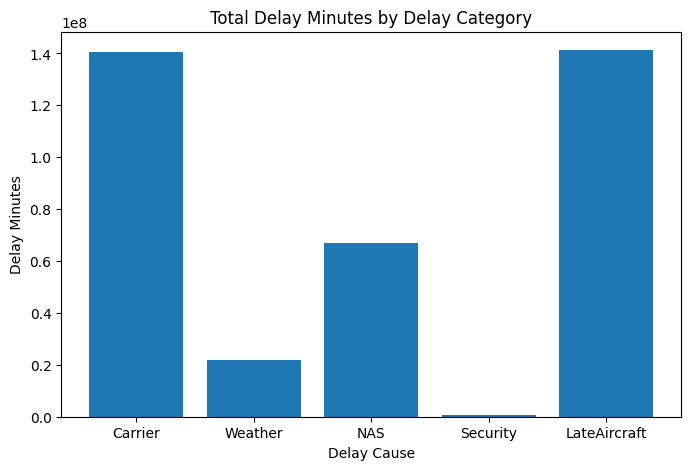

In [15]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

delay_causes = (
    df.select(
        F.sum("CarrierDelay").alias("Carrier"),
        F.sum("WeatherDelay").alias("Weather"),
        F.sum("NASDelay").alias("NAS"),
        F.sum("SecurityDelay").alias("Security"),
        F.sum("LateAircraftDelay").alias("LateAircraft")
    )
)

cause_pd = delay_causes.toPandas().T.reset_index()
cause_pd.columns = ["DelayCause", "Minutes"]

plt.figure(figsize=(8,5))
plt.bar(cause_pd["DelayCause"], cause_pd["Minutes"])

plt.title("Total Delay Minutes by Delay Category")
plt.xlabel("Delay Cause")
plt.ylabel("Delay Minutes")

plt.show()

In [11]:
df = spark.read.parquet(
    "/content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_core_2020_2024"
)
print(f"Columns: {len(df.columns)}")
print(f"Rows: {df.count():,}")

AnalysisException: [UNABLE_TO_INFER_SCHEMA] Unable to infer schema for Parquet. It must be specified manually.

In [ ]:
print(type(df))

In [5]:
from pathlib import Path

single_files = sorted(WORKING_DIR.glob("*2020_1.csv"))

if not single_files:
    raise FileNotFoundError(
        "Could not find the January 2020 CSV. "
        "Check WORKING_DIR and list its contents."
    )

single_file = single_files[0]

print(f"Testing file: {single_file.name}")

test_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(str(single_file))
)

print(f"Columns found: {len(test_df.columns)}")
print(f"Last five columns: {test_df.columns[-5:]}")

test_df.select(
    "Year",
    "Month",
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "DepDelay",
    "ArrDelay",
    "Cancelled"
).show(5, truncate=False)

Testing file: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2020_1.csv
Columns found: 110
Last five columns: ['Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum', '_c109']
+----+-----+----------+-----------------+------+----+--------+--------+---------+
|Year|Month|FlightDate|Reporting_Airline|Origin|Dest|DepDelay|ArrDelay|Cancelled|
+----+-----+----------+-----------------+------+----+--------+--------+---------+
|2020|1    |2020-01-17|B6               |PBI   |BDL |-14.00  |-11.00  |0.00     |
|2020|1    |2020-01-18|B6               |PBI   |BDL |-14.00  |-9.00   |0.00     |
|2020|1    |2020-01-19|B6               |PBI   |BDL |7.00    |-6.00   |0.00     |
|2020|1    |2020-01-20|B6               |PBI   |BDL |-7.00   |4.00    |0.00     |
|2020|1    |2020-01-21|B6               |PBI   |BDL |12.00   |6.00    |0.00     |
+----+-----+----------+-----------------+------+----+--------+--------+---------+
only showing top 5 rows



In [7]:
from pyspark.sql import functions as F

working_pattern = str(WORKING_DIR / "*.csv")

raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(working_pattern)
    .withColumn("source_file", F.input_file_name())
)

print(f"Columns read: {len(raw_df.columns)}")
print(f"Input partitions: {raw_df.rdd.getNumPartitions()}")

Columns read: 111
Input partitions: 112


In [8]:
from pyspark.sql.types import (
    IntegerType,
    DoubleType,
    DateType,
)

core_string_columns = [
    "Reporting_Airline",
    "IATA_CODE_Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "OriginCityName",
    "OriginState",
    "OriginStateName",
    "Dest",
    "DestCityName",
    "DestState",
    "DestStateName",
    "DepTimeBlk",
    "ArrTimeBlk",
    "CancellationCode",
]

integer_columns = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DOT_ID_Reporting_Airline",
    "CRSDepTime",
    "DepTime",
    "DepDel15",
    "CRSArrTime",
    "ArrTime",
    "ArrDel15",
    "Cancelled",
    "Diverted",
    "DistanceGroup",
]

double_columns = [
    "DepDelay",
    "DepDelayMinutes",
    "ArrDelay",
    "ArrDelayMinutes",
    "CRSElapsedTime",
    "ActualElapsedTime",
    "AirTime",
    "Distance",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]

selected_df = raw_df.select(
    *[F.col(column).cast("string").alias(column) for column in core_string_columns],
    *[F.col(column).cast("int").alias(column) for column in integer_columns],
    *[F.to_date(F.col("FlightDate"), "yyyy-MM-dd").alias("FlightDate")],
    *[F.col(column).cast("double").alias(column) for column in double_columns],
    F.col("source_file")
)

clean_df = (
    selected_df
    .filter(F.col("Year").between(2020, 2024))
    .filter(F.col("Month").between(1, 12))
    .filter(F.col("FlightDate").isNotNull())
    .withColumn("ScheduledDepHour", F.floor(F.col("CRSDepTime") / 100).cast("int"))
    .withColumn("FlightMonth", F.trunc(F.col("FlightDate"), "month"))
)

print(f"Core columns retained: {len(selected_df.columns) - 1}")
print(f"Columns after derived fields: {len(clean_df.columns)}")

clean_df.printSchema()

Core columns retained: 43
Columns after derived fields: 46
root
 |-- Reporting_Airline: string (nullable = true)
 |-- IATA_CODE_Reporting_Airline: string (nullable = true)
 |-- Flight_Number_Reporting_Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- OriginCityName: string (nullable = true)
 |-- OriginState: string (nullable = true)
 |-- OriginStateName: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- DestCityName: string (nullable = true)
 |-- DestState: string (nullable = true)
 |-- DestStateName: string (nullable = true)
 |-- DepTimeBlk: string (nullable = true)
 |-- ArrTimeBlk: string (nullable = true)
 |-- CancellationCode: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- DOT_ID_Reporting_Airline: integer (nullable = true)
 |-- CRSDepTime: integer (nullable =

In [9]:
import shutil

PROCESSING_PATH = PROCESSED_DIR / "airline_core_2020_2024"

if PROCESSING_PATH.exists():
    shutil.rmtree(PROCESSING_PATH)
    print("Removed previous processing output.")

(
    clean_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .partitionBy("Year", "Month")
    .parquet(str(PROCESSING_PATH))
)

print(f"Processing dataset written to: {PROCESSING_PATH}")

Removed previous processing output.


ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/usr/local/lib/python3.13/dist-packages/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/socket.py", line 723, in readinto
    return self._sock.recv_into(b)
           ~~~~~~~~~~~~~~~~~~~~^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [ ]:
def folder_size_bytes(folder: Path) -> int:
    return sum(
        path.stat().st_size
        for path in folder.rglob("*")
        if path.is_file()
    )

processing_bytes = folder_size_bytes(PROCESSING_PATH)

print(f"Processing dataset size: {processing_bytes / (1024 ** 3):.3f} GiB")
print(f"Processing dataset size: {processing_bytes / 1_000_000_000:.3f} GB")

parquet_files = list(PROCESSING_PATH.rglob("*.parquet"))
print(f"Parquet data files: {len(parquet_files)}")

partition_dirs = [
    path for path in PROCESSING_PATH.rglob("Month=*")
    if path.is_dir()
]
print(f"Year-month partitions: {len(partition_dirs)}")

Processing dataset size: 0.631 GiB
Processing dataset size: 0.677 GB
Parquet data files: 60
Year-month partitions: 60


In [ ]:
FULL_PROCESSING_PATH = PROCESSED_DIR / "airline_full_2020_2024_uncompressed"

if FULL_PROCESSING_PATH.exists():
    shutil.rmtree(FULL_PROCESSING_PATH)
    print("Removed previous full-schema processing output.")

full_processing_df = (
    raw_df
    .filter(F.col("Year").cast("int").between(2020, 2024))
    .filter(F.col("Month").cast("int").between(1, 12))
    .drop("_c109")
    .withColumn("Year", F.col("Year").cast("int"))
    .withColumn("Month", F.col("Month").cast("int"))
    .withColumn("FlightDate", F.to_date(F.col("FlightDate"), "yyyy-MM-dd"))
    .filter(F.col("FlightDate").isNotNull())
)

(
    full_processing_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .option("compression", "uncompressed")
    .partitionBy("Year", "Month")
    .parquet(str(FULL_PROCESSING_PATH))
)

print(f"Full processing dataset written to: {FULL_PROCESSING_PATH}")

Full processing dataset written to: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_full_2020_2024_uncompressed


In [ ]:
full_processing_bytes = folder_size_bytes(FULL_PROCESSING_PATH)

print(f"Full processing dataset size: {full_processing_bytes / (1024 ** 3):.3f} GiB")
print(f"Full processing dataset size: {full_processing_bytes / 1_000_000_000:.3f} GB")

full_parquet_files = list(FULL_PROCESSING_PATH.rglob("*.parquet"))
print(f"Full Parquet data files: {len(full_parquet_files)}")

Full processing dataset size: 1.125 GiB
Full processing dataset size: 1.208 GB
Full Parquet data files: 60


In [ ]:
CSV_PROCESSING_PATH = PROCESSED_DIR / "airline_full_2020_2024_csv"

if CSV_PROCESSING_PATH.exists():
    shutil.rmtree(CSV_PROCESSING_PATH)
    print("Removed previous CSV processing output.")

(
    full_processing_df
    .repartition(60, "Year", "Month")
    .write
    .mode("overwrite")
    .option("header", True)
    .option("compression", "none")
    .partitionBy("Year", "Month")
    .csv(str(CSV_PROCESSING_PATH))
)

print(f"CSV processing dataset written to: {CSV_PROCESSING_PATH}")

CSV processing dataset written to: /content/drive/MyDrive/MIT805_Airline_Delays/data/processed/airline_full_2020_2024_csv


In [ ]:
csv_processing_bytes = folder_size_bytes(CSV_PROCESSING_PATH)

print(f"CSV processing dataset size: {csv_processing_bytes / (1024 ** 3):.3f} GiB")
print(f"CSV processing dataset size: {csv_processing_bytes / 1_000_000_000:.3f} GB")

csv_part_files = list(CSV_PROCESSING_PATH.rglob("*.csv"))
print(f"CSV processing data files: {len(csv_part_files)}")

csv_partition_dirs = [
    path for path in CSV_PROCESSING_PATH.rglob("Month=*")
    if path.is_dir()
]
print(f"Year-month partitions: {len(csv_partition_dirs)}")

CSV processing dataset size: 14.586 GiB
CSV processing dataset size: 15.662 GB
CSV processing data files: 60
Year-month partitions: 60


In [6]:
total_flights = clean_df.count()

print(f"Total flight records: {total_flights:,}")

NameError: name 'clean_df' is not defined